In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import Counter
from IPython.display import Audio, display

In [ ]:
CONFIG = {
    "raw_dir"    : "/content/icbhi_dataset/raw/Respiratory_Sound_Database/Respiratory_Sound_Database",      # downloaded .wav + .txt
    "cycles_dir" : "/content/icbhi_dataset/cycles",   # segmented cycles go here
    "splits_file": "/content/icbhi_dataset/raw/ICBHI_challenge_train_test.txt",


    "target_sr"  : 22050,

    "class_map" : {
        (0,0): "Normal",
        (1,0): "Crackle",
        (0,1): "Wheeze",
        (1,1): "Both",
    },
    "classes"    : ["Normal", "Crackle", "Wheeze", "Both"],

    "seed" : 42,

}

In [ ]:

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d vbookshelf/respiratory-sound-database \
       -p /content/icbhi_dataset/raw --unzip --quiet

print("Download complete.")

Download complete.


In [ ]:
def parse_annotation_file(txt_path: str) -> pd.DataFrame:
  """
    Read one ICBHI annotation .txt file and return a DataFrame.

    Args:
        txt_path: path to the .txt annotation file

    Returns:
        DataFrame with columns:
            start    → cycle start time in seconds (float)
            end      → cycle end time in seconds (float)
            crackle  → 1 if crackles present, else 0 (int)
            wheeze   → 1 if wheeze present, else 0 (int)
            label    → human-readable class string ("Normal", "Crackle", etc.)
    """

  df = pd.read_csv(
        txt_path,
        sep="\t",
        header=None,
        names=["start", "end", "crackle", "wheeze"],
    )
  df["crackle"] = df["crackle"].astype(int)
  df["wheeze"] = df["wheeze"].astype(int)


  df["label"] = df.apply(
        lambda row: CONFIG["class_map"][(row["crackle"], row["wheeze"])],
        axis=1
    )

  return df

In [ ]:
def demo_annotation_parsing(raw_dir: str):
    """Show the first annotation file we find."""
    audio_dir = os.path.join(raw_dir, "audio_and_txt_files")

    # Find any .txt file
    txt_files = list(Path(audio_dir).glob("*.txt"))
    if not txt_files:
        print("No annotation files found. Check your raw_dir path.")
        return

    sample_txt = str(txt_files[0])
    print(f"Parsing: {os.path.basename(sample_txt)}\n")

    df = parse_annotation_file(sample_txt)
    print(df.to_string(index=False))
    print(f"\nCycles in this recording: {len(df)}")
    print(f"Label counts: {df['label'].value_counts().to_dict()}")

In [ ]:
demo_annotation_parsing(CONFIG["raw_dir"])

No annotation files found. Check your raw_dir path.


In [ ]:
def build_master_annotation(raw_dir: str, splits_file: str) -> pd.DataFrame:
  """
    Parse all annotation files and combine into one master DataFrame.

    Also attaches:
        - patient_id  → extracted from filename (first number, e.g. "101")
        - split       → "train" or "test" from official ICBHI split file
        - wav_path    → full path to the source .wav file
        - txt_path    → full path to the annotation .txt file

    Args:
        raw_dir     : path to the raw dataset root
        splits_file : path to ICBHI_challenge_train_test.txt

    Returns:
        master DataFrame with one row per breathing cycle
    """
  audio_dir = os.path.join(raw_dir, "audio_and_txt_files")
   # The split file has one filename per line, labeled "train" or "test"
  # Format:  101_1b1_Al_sc_Litt3200   train
  split_df = pd.read_csv(
      splits_file,
      sep="\t",
      header=None,
      names=["filename", "split"]
  )
  print("\n--- Split file content (first 5 rows):\n", split_df.head())

  # Build a dict: filename_stem → "train" or "test"
  split_dict = dict(zip(split_df["filename"], split_df["split"]))

  all_rows = []   # collect rows from every file

  txt_files = sorted(Path(audio_dir).glob("*.txt"))
  print(f"\nFound {len(txt_files)} annotation files...")

  # Limit to first few files for inspection
  _debug_count = 0
  for txt_path in txt_files:
      stem = txt_path.stem               # e.g. "101_1b1_Al_sc_Litt3200"
      wav_path = txt_path.with_suffix(".wav")  # matching .wav file

      if not wav_path.exists():
          # Skip if audio file missing (shouldn't happen in clean download)
          print(f"  WARNING: No .wav found for {stem}, skipping.")
          continue

      # Extract patient ID — always the first part before the first underscore
      patient_id = stem.split("_")[0]    # "101_1b1_..." → "101"

      # Get train/test label from the split dict
      split = split_dict.get(stem, "unknown")

      if _debug_count < 5: # Print first 5 stems and their resolved split
          print(f"  Debug: Stem '{stem}' resolved to split '{split}'")
          _debug_count += 1

      # Parse this file's annotation
      df = parse_annotation_file(str(txt_path))

      # Attach metadata columns to every row
      df["filename"]   = stem
      df["patient_id"] = patient_id
      df["split"]      = split
      df["wav_path"]   = str(wav_path)
      df["txt_path"]   = str(txt_path)

      all_rows.append(df)

  # Stack all individual DataFrames into one master table
  master = pd.concat(all_rows, ignore_index=True)

  # Add a unique cycle_id for each row (useful for saving files later)
  master["cycle_id"] = master.index

  print(f"\nMaster DataFrame built.")
  print(f"Total breathing cycles : {len(master)}")
  print(f"Unique patients        : {master['patient_id'].nunique()}")
  print(f"Train cycles           : {(master['split'] == 'train').sum()}")
  print(f"Test cycles            : {(master['split'] == 'test').sum()}")

  return master

In [ ]:
from pathlib import Path
import requests
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

url = (
    "https://bhichallenge.med.auth.gr/sites/default/files/"
    "ICBHI_final_database/ICBHI_challenge_train_test.txt"
)

split_path = Path("/content/icbhi_dataset/raw/ICBHI_challenge_train_test.txt")

response = requests.get(
    url,
    verify=False,       # Required because the server certificate is expired
    timeout=60
)

response.raise_for_status()

content = response.content

# Prevent accidentally saving another HTML error page
text_start = content[:1000].lower()
if b"<html" in text_start or b"<!doctype" in text_start:
    raise RuntimeError(
        "The server returned an HTML error page instead of the split file."
    )

split_path.write_bytes(content)

print("Downloaded:", split_path)
print("Size:", split_path.stat().st_size, "bytes")

FileNotFoundError: [Errno 2] No such file or directory: '\\content\\icbhi_dataset\\raw\\ICBHI_challenge_train_test.txt'

In [ ]:
master_df = build_master_annotation(CONFIG["raw_dir"], CONFIG["splits_file"])


--- Split file content (first 5 rows):
                  filename  split
0  101_1b1_Al_sc_Meditron   test
1  101_1b1_Pr_sc_Meditron   test
2  102_1b1_Ar_sc_Meditron   test
3  103_2b2_Ar_mc_LittC2SE  train
4  104_1b1_Al_sc_Litt3200   test

Found 920 annotation files...
  Debug: Stem '101_1b1_Al_sc_Meditron' resolved to split 'test'
  Debug: Stem '101_1b1_Pr_sc_Meditron' resolved to split 'test'
  Debug: Stem '102_1b1_Ar_sc_Meditron' resolved to split 'test'
  Debug: Stem '103_2b2_Ar_mc_LittC2SE' resolved to split 'train'
  Debug: Stem '104_1b1_Al_sc_Litt3200' resolved to split 'test'

Master DataFrame built.
Total breathing cycles : 6898
Unique patients        : 126
Train cycles           : 4131
Test cycles            : 2756


In [ ]:
from pathlib import Path

print(Path(split_path).read_text(encoding="utf-8")[:500])

101_1b1_Al_sc_Meditron	test
101_1b1_Pr_sc_Meditron	test
102_1b1_Ar_sc_Meditron	test
103_2b2_Ar_mc_LittC2SE	train
104_1b1_Al_sc_Litt3200	test
104_1b1_Ar_sc_Litt3200	test
104_1b1_Ll_sc_Litt3200	test
104_1b1_Lr_sc_Litt3200	test
104_1b1_Pl_sc_Litt3200	test
104_1b1_Pr_sc_Litt3200	test
105_1b1_Tc_sc_Meditron	train
106_2b1_Pl_mc_LittC2SE	train
106_2b1_Pr_mc_LittC2SE	train
107_2b3_Al_mc_AKGC417L	train
107_2b3_Ar_mc_AKGC417L	train
107_2b3_Ll_mc_AKGC417L	train
107_2b3_Lr_mc_AKGC417L	train
107_2b3_Pl_mc_AK


In [ ]:
import pandas as pd

split_df = pd.read_csv(
    split_path,
    sep=r"\s+",
    header=None,
    names=["filename", "split"]
)

print(split_df.head(10))
print()
print(split_df["split"].value_counts())

                 filename  split
0  101_1b1_Al_sc_Meditron   test
1  101_1b1_Pr_sc_Meditron   test
2  102_1b1_Ar_sc_Meditron   test
3  103_2b2_Ar_mc_LittC2SE  train
4  104_1b1_Al_sc_Litt3200   test
5  104_1b1_Ar_sc_Litt3200   test
6  104_1b1_Ll_sc_Litt3200   test
7  104_1b1_Lr_sc_Litt3200   test
8  104_1b1_Pl_sc_Litt3200   test
9  104_1b1_Pr_sc_Litt3200   test

split
train    539
test     381
Name: count, dtype: int64


In [ ]:
# or use this
"""
!wget --no-check-certificate \
  -O /content/icbhi_dataset/raw/ICBHI_challenge_train_test.txt \
  "https://bhichallenge.med.auth.gr/sites/default/files/ICBHI_final_database/ICBHI_challenge_train_test.txt"
"""

"""
  !head -10 /content/icbhi_dataset/raw/ICBHI_challenge_train_test.txt
"""

'\n  !head -10 /content/icbhi_dataset/raw/ICBHI_challenge_train_test.txt\n'

In [ ]:
master_df = build_master_annotation(
    CONFIG["raw_dir"],
    CONFIG["splits_file"]
)


--- Split file content (first 5 rows):
                  filename  split
0  101_1b1_Al_sc_Meditron   test
1  101_1b1_Pr_sc_Meditron   test
2  102_1b1_Ar_sc_Meditron   test
3  103_2b2_Ar_mc_LittC2SE  train
4  104_1b1_Al_sc_Litt3200   test

Found 920 annotation files...
  Debug: Stem '101_1b1_Al_sc_Meditron' resolved to split 'test'
  Debug: Stem '101_1b1_Pr_sc_Meditron' resolved to split 'test'
  Debug: Stem '102_1b1_Ar_sc_Meditron' resolved to split 'test'
  Debug: Stem '103_2b2_Ar_mc_LittC2SE' resolved to split 'train'
  Debug: Stem '104_1b1_Al_sc_Litt3200' resolved to split 'test'

Master DataFrame built.
Total breathing cycles : 6898
Unique patients        : 126
Train cycles           : 4131
Test cycles            : 2756


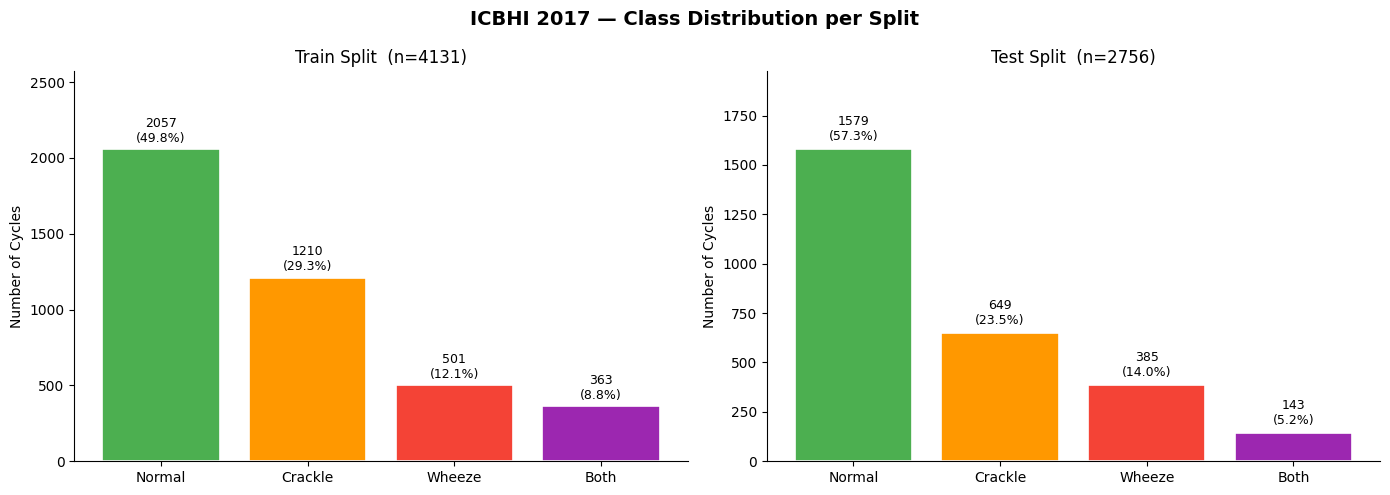


Key observation: Normal >> Crackle >> Wheeze >> Both
This imbalance is WHY WeightedRandomSampler + SpecAugment will be needed.


In [ ]:
def plot_class_distribution(master_df: pd.DataFrame):
    """
    Plot class counts for train and test splits side by side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("ICBHI 2017 — Class Distribution per Split", fontsize=14, fontweight="bold")

    colors = {
        "Normal" : "#4CAF50",   # green — healthy
        "Crackle": "#FF9800",   # orange — abnormal
        "Wheeze" : "#F44336",   # red — abnormal
        "Both"   : "#9C27B0",   # purple — most severe
    }

    for ax, split in zip(axes, ["train", "test"]):
        split_df = master_df[master_df["split"] == split]
        counts   = split_df["label"].value_counts()

        # Reorder to match CONFIG["classes"] order
        counts = counts.reindex(CONFIG["classes"], fill_value=0)

        bars = ax.bar(
            counts.index,
            counts.values,
            color=[colors[c] for c in counts.index],
            edgecolor="white",
            linewidth=1.2
        )

        # Annotate each bar with its count and percentage
        total = counts.sum()
        for bar, count in zip(bars, counts.values):
            pct = 100 * count / total
            ax.text(
                bar.get_x() + bar.get_width() / 2,  # x: center of bar
                bar.get_height() + 30,               # y: just above bar
                f"{count}\n({pct:.1f}%)",            # label text
                ha="center", va="bottom", fontsize=9
            )

        ax.set_title(f"{split.capitalize()} Split  (n={total})", fontsize=12)
        ax.set_ylabel("Number of Cycles")
        ax.set_ylim(0, counts.max() * 1.25)   # headroom for annotations
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nKey observation: Normal >> Crackle >> Wheeze >> Both")
    print("This imbalance is WHY WeightedRandomSampler + SpecAugment will be needed.")

plot_class_distribution(master_df)

In [ ]:
def demonstrate_audio_loading(wav_path: str, target_sr: int = 22050):
    """
    Load one .wav file and explain what librosa gives you.

    Args:
        wav_path  : path to any .wav file in the dataset
        target_sr : the sample rate to resample to
    """
    y, sr = librosa.load(
        wav_path,
        sr = target_sr,
        mono=True
    )

    duration = len(y) / sr   # total duration in seconds

    print("=" * 10)
    print(f"File          : {os.path.basename(wav_path)}")
    print(f"Sample rate   : {sr} Hz")
    print(f"Num samples   : {len(y):,}")
    print(f"Duration      : {duration:.2f} seconds")
    print(f"y dtype       : {y.dtype}")
    print(f"y min/max     : {y.min():.4f} / {y.max():.4f}")
    print(f"y shape       : {y.shape}")
    print("=" * 10)
    print("\nIntuition:")
    print(f"  {sr} samples/sec × {duration:.1f} sec = {len(y):,} numbers")
    print(f"  Each number = air pressure at that instant (range: -1.0 to +1.0)")

    # Play the audio directly in Colab
    print("\nPlaying audio in Colab...")
    display(Audio(y, rate=sr))
    return y, sr

In [ ]:
sample_wav_path = master_df['wav_path'].iloc[0]
target_sr = CONFIG['target_sr']

y, sr = demonstrate_audio_loading(wav_path=sample_wav_path, target_sr=target_sr)

File          : 101_1b1_Al_sc_Meditron.wav
Sample rate   : 22050 Hz
Num samples   : 441,000
Duration      : 20.00 seconds
y dtype       : float32
y min/max     : -0.2001 / 0.4147
y shape       : (441000,)

Intuition:
  22050 samples/sec × 20.0 sec = 441,000 numbers
  Each number = air pressure at that instant (range: -1.0 to +1.0)

Playing audio in Colab...


In [ ]:
import os

# PART 7 — BREATHING CYCLE SEGMENTATION

# The ICBHI labels are per CYCLE, not per full recording.
# A full recording might be 20 seconds with 8 breathing cycles.
# We need to slice each cycle into its own audio clip.

def segment_and_save_cycles(master_df: pd.DataFrame, cycles_dir: str, target_sr: int):
  """
    For every row in master_df (= every breathing cycle):
        1. Load the source .wav
        2. Slice the audio between start_time and end_time
        3. Save as a new .wav file in cycles_dir/split/label/

    This creates the folder structure  needed for ImageFolder later
    (after Phase 2 converts these to spectrograms).

    Args:
        master_df  : the master DataFrame from build_master_dataframe()
        cycles_dir : where to save segmented cycle .wav files
        target_sr  : sample rate to save at
    """
  # Cache loaded audio files to avoid re-reading the same .wav repeatedly.
  # One recording can have 8+ cycles — no need to reload 8 times.
  audio_cache = {}

  saved   = 0
  skipped = 0

  for _, row in master_df.iterrows():
        # ── Build the output path ─────────────────────────────────────────
        # Structure: cycles_dir / split / label / filename_cycleID.wav
        # Example:   cycles/train/Crackle/101_1b1_Al_sc_Litt3200_cycle003.wav
    out_dir = os.path.join(cycles_dir, row["split"], row["label"])
    os.makedirs(out_dir, exist_ok=True)

    cycle_filename = f"{row['filename']}_cycle{row['cycle_id']:04d}.wav"
    out_path = os.path.join(out_dir, cycle_filename)

    if os.path.exists(out_path):
        # Skip if already saved (resume-safe, same pattern as your CNN phases)
        skipped += 1
        continue

        # ── Load audio (from cache if already loaded) ─────────────────────
    wav_path = row["wav_path"]
    if wav_path not in audio_cache:
        y, sr = librosa.load(wav_path, sr=target_sr, mono=True)
        audio_cache[wav_path] = (y, sr)
    else:
        y, sr = audio_cache[wav_path]

        # ── Slice the cycle ───────────────────────────────────────────────
        # Convert timestamps (seconds) → sample indices
    start_sample = int(row["start"] * sr)   # e.g. 0.036s × 22050 = 794
    end_sample   = int(row["end"]   * sr)   # e.g. 1.154s × 22050 = 25456

    cycle_audio = y[start_sample:end_sample]  # numpy slice = fast

    # Skip cycles that are too short (< 0.5s) — likely annotation errors
    min_samples = int(0.5 * sr)   # 0.5 seconds × 22050 = 11025 samples
    if len(cycle_audio) < min_samples:
        skipped += 1
        continue

        # ── Save the cycle ────────────────────────────────────────────────
    sf.write(out_path, cycle_audio, sr)   # soundfile handles wav encoding
    saved += 1

  print(f"\nSegmentation complete.")
  print(f"Saved   : {saved} cycles")
  print(f"Skipped : {skipped} cycles (already exist or too short)")

  # Show what the folder structure looks like
  print("\nFolder structure created:")
  for split in ["train", "test"]:
    for label in CONFIG["classes"]:
      folder = os.path.join(cycles_dir, split, label)
      if os.path.exists(folder):
        n = len(os.listdir(folder))
        print(f"  {split}/{label:<8} → {n} cycles")

In [ ]:
segment_and_save_cycles(master_df, CONFIG["cycles_dir"], CONFIG["target_sr"])


Segmentation complete.
Saved   : 0 cycles
Skipped : 6898 cycles (already exist or too short)

Folder structure created:
  train/Normal   → 2031 cycles
  train/Crackle  → 1209 cycles
  train/Wheeze   → 499 cycles
  train/Both     → 363 cycles
  test/Normal   → 1571 cycles
  test/Crackle  → 647 cycles
  test/Wheeze   → 383 cycles
  test/Both     → 143 cycles


In [ ]:
# PART 8 — WAVEFORM VISUALIZATION (THE KEY LEARNING MOMENT)
# =============================================================================
# Now you see WHY different diseases look different in audio.
#
# CRACKLES: short, explosive discontinuous sounds
#   → Waveform shows sharp spikes at irregular intervals
#   → Caused by: sudden opening of closed airways (pneumonia, fibrosis)
#
# WHEEZES: continuous musical tones
#   → Waveform shows sustained oscillation (like a sine wave)
#   → Caused by: narrowed airways vibrating (asthma, COPD)
#
# NORMAL: smooth, quiet, rhythmic breathing
#   → Waveform shows low-amplitude gentle oscillations

def plot_waveforms_by_class(cycles_dir: str, target_sr: int, num_examples: int = 2):
    """
    Plot sample waveforms for each class side by side.
    This is your intuition-building moment for the audio domain.

    Args:
        cycles_dir   : path to segmented cycles folder
        target_sr    : sample rate
        num_examples : how many examples to show per class
    """
    fig, axes = plt.subplots(
        len(CONFIG["classes"]), num_examples,
        figsize=(14, 4 * len(CONFIG["classes"]))
    )
    fig.suptitle(
        "Lung Sound Waveforms — What Each Class Looks Like in Time Domain",
        fontsize=13, fontweight="bold", y=1.01
    )

    class_descriptions = {
        "Normal" : "Smooth, quiet, rhythmic oscillations",
        "Crackle": "Sharp explosive spikes — sudden airway openings",
        "Wheeze" : "Sustained oscillation — narrowed airway vibration",
        "Both"   : "Combination of spikes and sustained oscillation",
    }

    np.random.seed(CONFIG["seed"])

    for row_idx, label in enumerate(CONFIG["classes"]):
        # Find available cycle files for this class (train split)
        class_folder = os.path.join(cycles_dir, "train", label)
        if not os.path.exists(class_folder):
            print(f"  No samples found for {label} yet. Run segmentation first.")
            continue

        wav_files = list(Path(class_folder).glob("*.wav"))
        if not wav_files:
            continue

        # Pick random examples
        chosen = np.random.choice(
            wav_files,
            size=min(num_examples, len(wav_files)),
            replace=False
        )

        for col_idx, wav_file in enumerate(chosen):
            ax = axes[row_idx][col_idx]

            # Load this cycle
            y, sr = librosa.load(str(wav_file), sr=target_sr)

            # Time axis in seconds
            time_axis = np.linspace(0, len(y) / sr, num=len(y))

            # Plot the waveform
            ax.plot(
                time_axis, y,
                linewidth=0.5,
                color=["#4CAF50","#FF9800","#F44336","#9C27B0"][row_idx],
                alpha=0.8
            )
            ax.set_xlim(0, len(y) / sr)
            ax.set_ylim(-1.0, 1.0)   # amplitude always in [-1, 1] after librosa

            # Labels
            if col_idx == 0:
                ax.set_ylabel(f"{label}\n{class_descriptions[label]}", fontsize=9)
            if row_idx == len(CONFIG["classes"]) - 1:
                ax.set_xlabel("Time (seconds)")

            ax.set_title(f"Example {col_idx + 1}", fontsize=9)
            ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("waveforms_by_class.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nStudy these waveforms carefully before moving to Phase 2.")
    print("The patterns you see here will become visible features in mel-spectrograms.")



In [ ]:
# PART 9 — AUDIO PLAYBACK IN COLAB
# =============================================================================
# Listen to actual lung sounds. This is important — understanding the domain
# through your ears makes you a better model designer.

def play_class_examples(cycles_dir: str, target_sr: int):
    """
    Play one audio example per class directly in Colab.
    Run this cell and listen carefully to each sound.
    """
    np.random.seed(CONFIG["seed"])

    for label in CONFIG["classes"]:
        class_folder = os.path.join(cycles_dir, "train", label)
        wav_files = list(Path(class_folder).glob("*.wav"))

        if not wav_files:
            print(f"{label}: no files found")
            continue

        chosen = np.random.choice(wav_files)
        y, sr = librosa.load(str(chosen), sr=target_sr)

        duration = len(y) / sr
        print(f"\n{'='*40}")
        print(f"Class    : {label}")
        print(f"File     : {os.path.basename(chosen)}")
        print(f"Duration : {duration:.2f}s")
        print(f"Listen   ↓")
        display(Audio(y, rate=sr))


# =============================================================================
# PART 10 — PHASE 1 SUMMARY: DATA STATISTICS REPORT
# =============================================================================

def phase1_summary_report(master_df: pd.DataFrame):
    """Print a clean summary of what Phase 1 produced."""

    print("\n" + "="*55)
    print("  PHASE 1 COMPLETE — DATA SUMMARY REPORT")
    print("="*55)

    total = len(master_df)
    print(f"\nTotal breathing cycles  : {total:,}")
    print(f"Unique patients         : {master_df['patient_id'].nunique()}")
    print(f"Unique recordings       : {master_df['filename'].nunique()}")

    print("\n── Class Distribution ────────────────────────────────")
    for label in CONFIG["classes"]:
        n   = (master_df["label"] == label).sum()
        pct = 100 * n / total
        bar = "█" * int(pct / 2)
        print(f"  {label:<8} {n:>5}  ({pct:5.1f}%)  {bar}")

    print("\n── Train / Test Split ────────────────────────────────")
    for split in ["train", "test"]:
        n   = (master_df["split"] == split).sum()
        pct = 100 * n / total
        print(f"  {split:<6}  {n:>5}  ({pct:.1f}%)")

    print("\n── Key Observations ──────────────────────────────────")
    print("  1. Normal cycles dominate (~53%) → class imbalance")
    print("  2. Wheeze + Both are minority classes (<10% combined)")
    print("  3. Split is by PATIENT (not cycle) → no data leakage")
    print("     (same patient never appears in both train and test)")
    print("\n  → These observations directly shape Phase 4 strategy:")
    print("    WeightedRandomSampler + SpecAugment on minority classes")

    print("\n── What Phase 2 Will Do ──────────────────────────────")
    print("  Convert every .wav cycle → mel-spectrogram → 224×224 PNG")
    print("  After Phase 2, this becomes a standard ImageFolder problem")
    print("  and your existing CNN pipeline takes over.")
    print("="*55)


File          : 133_2p4_Pl_mc_AKGC417L.wav
Sample rate   : 22050 Hz
Num samples   : 441,000
Duration      : 20.00 seconds
y dtype       : float32
y min/max     : -1.0024 / 1.0063
y shape       : (441000,)

Intuition:
  22050 samples/sec × 20.0 sec = 441,000 numbers
  Each number = air pressure at that instant (range: -1.0 to +1.0)

Playing audio in Colab...



Segmentation complete.
Saved   : 0 cycles
Skipped : 6898 cycles (already exist or too short)

Folder structure created:
  train/Normal   → 2031 cycles
  train/Crackle  → 1209 cycles
  train/Wheeze   → 499 cycles
  train/Both     → 363 cycles
  test/Normal   → 1571 cycles
  test/Crackle  → 647 cycles
  test/Wheeze   → 383 cycles
  test/Both     → 143 cycles


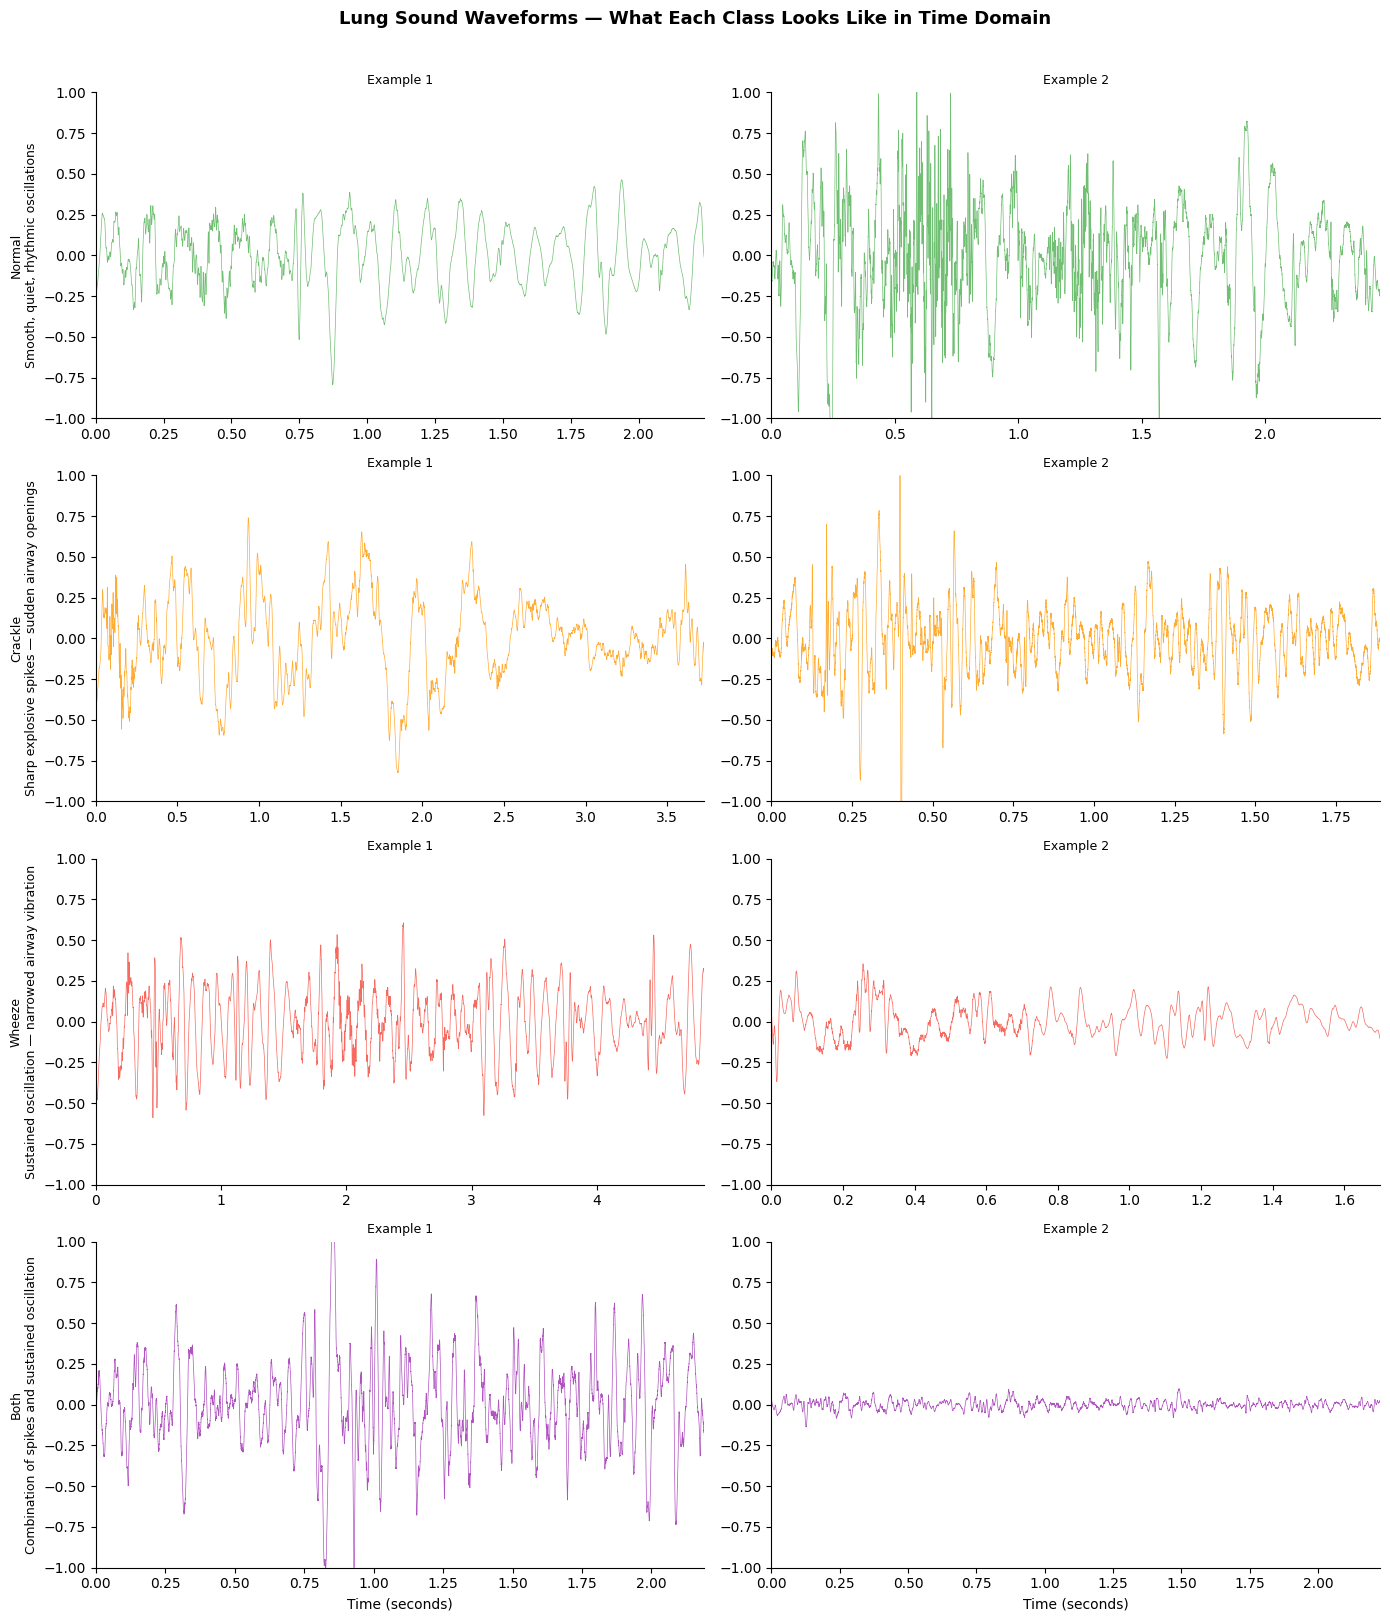


Study these waveforms carefully before moving to Phase 2.
The patterns you see here will become visible features in mel-spectrograms.

Class    : Normal
File     : 166_1p1_Ar_sc_Meditron_cycle3680.wav
Duration : 2.91s
Listen   ↓



Class    : Crackle
File     : 203_1p3_Pl_mc_AKGC417L_cycle5748.wav
Duration : 2.07s
Listen   ↓



Class    : Wheeze
File     : 204_2b5_Al_mc_AKGC417L_cycle5847.wav
Duration : 3.57s
Listen   ↓



Class    : Both
File     : 158_1p3_Pr_mc_AKGC417L_cycle3207.wav
Duration : 2.20s
Listen   ↓



  PHASE 1 COMPLETE — DATA SUMMARY REPORT

Total breathing cycles  : 6,898
Unique patients         : 126
Unique recordings       : 920

── Class Distribution ────────────────────────────────
  Normal    3642  ( 52.8%)  ██████████████████████████
  Crackle   1864  ( 27.0%)  █████████████
  Wheeze     886  ( 12.8%)  ██████
  Both       506  (  7.3%)  ███

── Train / Test Split ────────────────────────────────
  train    4131  (59.9%)
  test     2756  (40.0%)

── Key Observations ──────────────────────────────────
  1. Normal cycles dominate (~53%) → class imbalance
  2. Wheeze + Both are minority classes (<10% combined)
  3. Split is by PATIENT (not cycle) → no data leakage
     (same patient never appears in both train and test)

  → These observations directly shape Phase 4 strategy:
    WeightedRandomSampler + SpecAugment on minority classes

── What Phase 2 Will Do ──────────────────────────────
  Convert every .wav cycle → mel-spectrogram → 224×224 PNG
  After Phase 2, this becomes 

In [ ]:
audio_dir = os.path.join(CONFIG["raw_dir"], "audio_and_txt_files")
sample_wav = list(Path(audio_dir).glob("*.wav"))[0]
y, sr = demonstrate_audio_loading(str(sample_wav), CONFIG["target_sr"])
segment_and_save_cycles(master_df, CONFIG["cycles_dir"], CONFIG["target_sr"])
plot_waveforms_by_class(CONFIG["cycles_dir"], CONFIG["target_sr"])
play_class_examples(CONFIG["cycles_dir"], CONFIG["target_sr"])
phase1_summary_report(master_df)



In [ ]:
# RESPIRATORY AUDIO CNN — PHASE 2: SPECTROGRAM ENGINEERING
"""
What you're doing in this phase:

1. Understand WHAT a spectrogram is (theory first, code second)

2. Build three representations:
   - STFT
   - Mel-Spectrogram
   - MFCC

3. Learn why mel-scale fits respiratory audio perfectly

4. Standardize all cycles → 224×224 PNG images

5. Verify your ImageFolder structure is ready for Phase 3


New concepts introduced:

- Fourier Transform — what frequency content is in a signal
- Short-Time Fourier Transform (STFT) — frequency over time
- Mel scale — perceptual frequency warping
- Mel-Spectrogram — the final representation you'll train on
- MFCC — compact spectral fingerprint (you'll understand but not use)


Prerequisite:

Phase 1 must be complete — cycles_dir must be populated with .wav files.
"""

In [1]:
import os
import numpy as np
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image               # save spectrograms as PNG images
from tqdm import tqdm               # progress bar for bulk conversion
from collections import defaultdict

In [2]:
CONFIG = {
    #Paths (carry over from Phase 1)
    "cycles_dir"      : "/content/icbhi_dataset/cycles",      # Phase 1 output
    "spectrograms_dir": "/content/icbhi_dataset/spectrograms", # Phase 2 output

    # Audio
    "target_sr"   : 22050,      # sample rate (same as Phase 1)

    # Mel-Spectrogram Parameters (the core engineering decisions)
    # These are the numbers that turn audio into a 2D image.
    # Each one is explained in detail in Part 3.
    "n_fft"       : 1024,       # FFT window size (samples)
    "hop_length"  : 512,        # step between windows (samples)
    "n_mels"      : 128,        # number of mel filter banks (image height)
    "fmin"        : 50,         # minimum frequency to capture (Hz)
    "fmax"        : 2000,       # maximum frequency to capture (Hz)
                                # respiratory sounds live in 50–2000 Hz

    # Output Image
    "img_size"    : 224,        # final image size (224×224 for ResNet-50)

    # Classes
    "classes"     : ["Normal", "Crackle", "Wheeze", "Both"],

    # Misc
    "seed"        : 42,
    "colormap"    : "viridis",  # how to color the spectrogram
                                # options: "viridis", "magma", "inferno"
                                # viridis is most common in medical imaging
}

In [3]:
for split in ["train", "test"]:
    for label in CONFIG["classes"]:
        os.makedirs(
            os.path.join(CONFIG["spectrograms_dir"], split, label),
            exist_ok=True
        )

print("CONFIG ready.")
print(f"Mel parameters: n_fft={CONFIG['n_fft']}, hop={CONFIG['hop_length']}, "
      f"n_mels={CONFIG['n_mels']}, fmin={CONFIG['fmin']}, fmax={CONFIG['fmax']}")

CONFIG ready.
Mel parameters: n_fft=1024, hop=512, n_mels=128, fmin=50, fmax=2000


In [4]:
"""
PART 2 — THEORY: WHAT IS A SPECTROGRAM?


Read this section carefully. The code makes no sense without the theory.


The Problem with Raw Waveforms

In Phase 1 you plotted waveforms: amplitude vs time.

A waveform tells you WHEN something happened (a spike, an oscillation).

But it doesn't directly tell you WHAT FREQUENCY caused it.


Frequency is what distinguishes crackles from wheezes:

    Crackles → broadband bursts
               (energy across many frequencies at once)

    Wheezes  → narrowband tones
               (energy concentrated at one frequency)


A CNN needs to SEE frequency information to learn this distinction.

Waveforms hide frequency. Spectrograms reveal it.


── The Fourier Transform

Any signal = sum of sine waves at different frequencies.

The Fourier Transform decomposes a signal into its frequency components.


Example:

A chord on a guitar is 3 sine waves (3 notes) added together.

The Fourier Transform separates them back into the individual
notes + their amplitudes.


But the Fourier Transform gives you frequency content for the
WHOLE signal (no time information).

We need to know:

    "At 0.5 seconds, what frequencies were present?"


── The Short-Time Fourier Transform (STFT)

Solution:

Slide a window across the signal and compute the Fourier Transform
for each window.

Output:

    A 2D matrix of (frequency, time)

    Each cell = energy at that point.


This 2D matrix, when visualized, is a SPECTROGRAM.

    X-axis   = time
    Y-axis   = frequency
    Color    = energy (amplitude)


── The Mel Scale

Problem with STFT:

Linear frequency spacing is not ideal for human audio perception.

The difference between 100 Hz and 200 Hz sounds huge to human ears.

The difference between 8000 Hz and 8100 Hz sounds tiny.


The mel scale warps frequency to better match human perception:

    - Expands the low-frequency region
      (where we hear more detail)

    - Compresses the high-frequency region
      (where we hear less detail)


For lung sounds (50–2000 Hz), the mel scale is useful because:

    - Much of the important acoustic information is in the lower range.
    - We want higher resolution where it matters.


Mel-Spectrogram:

    = STFT with the frequency axis warped to the mel scale

    = the representation you'll train your CNN on


── From Audio to CNN Input

    .wav
      ↓
    librosa.load()
      ↓
    y (samples array)
      ↓
    librosa.feature.melspectrogram()
      ↓
    S (n_mels × time_frames)
      ↓
    librosa.power_to_db()
      ↓
    Log scale (more visible contrast)
      ↓
    Normalize to [0, 255]
      ↓
    Save as PNG
      ↓
    Resize to 224×224
      ↓
    CNN input
"""

'\nPART 2 — THEORY: WHAT IS A SPECTROGRAM?\n\n\nRead this section carefully. The code makes no sense without the theory.\n\n\nThe Problem with Raw Waveforms\n\nIn Phase 1 you plotted waveforms: amplitude vs time.\n\nA waveform tells you WHEN something happened (a spike, an oscillation).\n\nBut it doesn\'t directly tell you WHAT FREQUENCY caused it.\n\n\nFrequency is what distinguishes crackles from wheezes:\n\n    Crackles → broadband bursts\n               (energy across many frequencies at once)\n\n    Wheezes  → narrowband tones\n               (energy concentrated at one frequency)\n\n\nA CNN needs to SEE frequency information to learn this distinction.\n\nWaveforms hide frequency. Spectrograms reveal it.\n\n\n── The Fourier Transform\n\nAny signal = sum of sine waves at different frequencies.\n\nThe Fourier Transform decomposes a signal into its frequency components.\n\n\nExample:\n\nA chord on a guitar is 3 sine waves (3 notes) added together.\n\nThe Fourier Transform separates t

In [7]:
# PART 3 — PARAMETER DEEP DIVE: WHAT EACH NUMBER MEANS
def explain_parameters():
    """
    Print a detailed explanation of every mel-spectrogram parameter.
    Run this once to build intuition before generating any spectrograms.
    """
    sr         = CONFIG["target_sr"]
    n_fft      = CONFIG["n_fft"]
    hop_length = CONFIG["hop_length"]
    n_mels     = CONFIG["n_mels"]

    window_duration_ms = (n_fft / sr) * 1000
    hop_duration_ms    = (hop_length / sr) * 1000
    overlap_pct        = (1 - hop_length / n_fft) * 100
    freq_resolution    = sr / n_fft


    print("  MEL-SPECTROGRAM PARAMETER EXPLANATION")


    print(f"\nn_fft = {n_fft}")
    print(f"  → FFT window size in SAMPLES")
    print(f"  → Duration: {window_duration_ms:.1f} ms per analysis window")
    print(f"  → Frequency resolution: {freq_resolution:.1f} Hz per bin")
    print(f"  → Larger n_fft = better frequency resolution, worse time resolution")
    print(f"  → 1024 is a good balance for respiratory audio (~46ms windows)")

    print(f"\nhop_length = {hop_length}")
    print(f"  → How far to slide the window each step (in SAMPLES)")
    print(f"  → Duration: {hop_duration_ms:.1f} ms per step")
    print(f"  → Overlap: {overlap_pct:.0f}% between consecutive windows")
    print(f"  → Smaller hop = more time frames = wider image (more detail)")
    print(f"  → 512 = 50% overlap, standard for audio analysis")

    print(f"\nn_mels = {n_mels}")
    print(f"  → Number of mel filter banks = IMAGE HEIGHT")
    print(f"  → More mel bins = higher frequency resolution in image")
    print(f"  → 128 is standard; medical papers use 64–256")

    print(f"\nfmin = {CONFIG['fmin']} Hz, fmax = {CONFIG['fmax']} Hz")
    print(f"  → Frequency range to capture in the spectrogram")
    print(f"  → Lung sounds: 50 Hz (low rumbles) to 2000 Hz (high wheezes)")
    print(f"  → Cutting off at 2000 Hz removes irrelevant high-freq noise")

    print(f"\nImage output: {CONFIG['img_size']} × {CONFIG['img_size']} pixels")
    print(f"  → Resized to match ResNet-50 expected input (224×224)")
    print(f"  → 3-channel RGB (colormap converts grayscale → color)")


In [8]:
explain_parameters()

  MEL-SPECTROGRAM PARAMETER EXPLANATION

n_fft = 1024
  → FFT window size in SAMPLES
  → Duration: 46.4 ms per analysis window
  → Frequency resolution: 21.5 Hz per bin
  → Larger n_fft = better frequency resolution, worse time resolution
  → 1024 is a good balance for respiratory audio (~46ms windows)

hop_length = 512
  → How far to slide the window each step (in SAMPLES)
  → Duration: 23.2 ms per step
  → Overlap: 50% between consecutive windows
  → Smaller hop = more time frames = wider image (more detail)
  → 512 = 50% overlap, standard for audio analysis

n_mels = 128
  → Number of mel filter banks = IMAGE HEIGHT
  → More mel bins = higher frequency resolution in image
  → 128 is standard; medical papers use 64–256

fmin = 50 Hz, fmax = 2000 Hz
  → Frequency range to capture in the spectrogram
  → Lung sounds: 50 Hz (low rumbles) to 2000 Hz (high wheezes)
  → Cutting off at 2000 Hz removes irrelevant high-freq noise

Image output: 224 × 224 pixels
  → Resized to match ResNet-50 e

In [9]:
# PART 4 — THREE REPRESENTATIONS SIDE BY SIDE

# Build all three representations for the same audio clip.
# See how they differ — then understand why mel-spectrogram wins.


def compare_representations(wav_path: str):
    """
    Plot STFT spectrogram, Mel-Spectrogram, and MFCC
    for the same audio clip side by side.

    Args:
        wav_path: path to any .wav cycle file
    """
    # Load audio
    y, sr = librosa.load(wav_path, sr=CONFIG["target_sr"])

    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(
        f"Three Audio Representations — {Path(wav_path).stem}",
        fontsize=13, fontweight="bold"
    )

    # Row 1: Waveform (baseline reference)
    ax_wave = fig.add_subplot(4, 1, 1)
    time_axis = np.linspace(0, len(y) / sr, num=len(y))
    ax_wave.plot(time_axis, y, color="#2196F3", linewidth=0.5)
    ax_wave.set_title("Waveform (time domain — what Phase 1 showed you)")
    ax_wave.set_ylabel("Amplitude")
    ax_wave.set_xlabel("Time (s)")
    ax_wave.spines[["top", "right"]].set_visible(False)

    # Row 2: STFT Spectrogram
    # librosa.stft() → complex matrix → take magnitude → convert to dB
    ax_stft = fig.add_subplot(4, 1, 2)

    D = librosa.stft(y, n_fft=CONFIG["n_fft"], hop_length=CONFIG["hop_length"])
    # D shape: (n_fft//2 + 1, time_frames) — complex valued
    # |D| gives us magnitude (energy at each freq × time point)

    D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    # amplitude_to_db: converts to log scale (decibels)
    # Log scale is essential — audio energy spans many orders of magnitude
    # Without log scale, quiet sounds are invisible next to loud ones

    librosa.display.specshow(
        D_db,
        sr=sr,
        hop_length=CONFIG["hop_length"],
        x_axis="time",
        y_axis="hz",        # linear frequency axis
        ax=ax_stft,
        cmap=CONFIG["colormap"]
    )
    ax_stft.set_title("STFT Spectrogram (linear frequency — notice empty top half)")
    ax_stft.set_ylabel("Frequency (Hz)")
    plt.colorbar(ax_stft.collections[0], ax=ax_stft, format="%+2.0f dB")

    # Row 3: Mel-Spectrogram
    ax_mel = fig.add_subplot(4, 1, 3)

    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=CONFIG["n_fft"],
        hop_length=CONFIG["hop_length"],
        n_mels=CONFIG["n_mels"],
        fmin=CONFIG["fmin"],
        fmax=CONFIG["fmax"]
    )
    # S shape: (n_mels, time_frames) — power values (amplitude²)
    # n_mels=128 means 128 frequency bands (after mel warping)

    S_db = librosa.power_to_db(S, ref=np.max)
    # power_to_db: 10 * log10(S / ref)
    # ref=np.max means top of colorbar = 0 dB, everything else is negative

    librosa.display.specshow(
        S_db,
        sr=sr,
        hop_length=CONFIG["hop_length"],
        x_axis="time",
        y_axis="mel",       # mel-warped frequency axis
        fmin=CONFIG["fmin"],
        fmax=CONFIG["fmax"],
        ax=ax_mel,
        cmap=CONFIG["colormap"]
    )
    ax_mel.set_title("Mel-Spectrogram (mel frequency — expanded low-freq region, this is what we'll train on)")
    ax_mel.set_ylabel("Mel Frequency")
    plt.colorbar(ax_mel.collections[0], ax=ax_mel, format="%+2.0f dB")

    # Row 4: MFCC
    ax_mfcc = fig.add_subplot(4, 1, 4)

    mfccs = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13,          # 13 coefficients is the classic speech recognition default
        n_fft=CONFIG["n_fft"],
        hop_length=CONFIG["hop_length"]
    )
    # mfccs shape: (13, time_frames)
    # MFCCs are a compressed "fingerprint" of spectral shape
    # They throw away absolute energy, keeping only the shape
    # Useful for speech — less ideal for medical audio where energy matters

    librosa.display.specshow(
        mfccs,
        sr=sr,
        hop_length=CONFIG["hop_length"],
        x_axis="time",
        ax=ax_mfcc,
        cmap="coolwarm"
    )
    ax_mfcc.set_title("MFCC (13 coefficients — compact but discards energy info, not used for training)")
    ax_mfcc.set_ylabel("MFCC Coefficient")
    plt.colorbar(ax_mfcc.collections[0], ax=ax_mfcc)

    plt.tight_layout()
    plt.savefig("three_representations.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\nKey observations:")
    print("  STFT   → upper half of plot is empty (lung sounds < 2000 Hz)")
    print("  Mel    → full image used efficiently (mel warping fills the space)")
    print("  MFCC   → most compressed, but loses energy information we need")
    print("  Winner → Mel-Spectrogram ✓")




In [11]:
# PART 5 — MEL-SPECTROGRAM BY CLASS: THE VISUAL INTUITION
"""
This is the payoff of Part 2 theory. You'll see exactly why:

    - Crackles look like vertical bright streaks
      (broadband bursts)

    - Wheezes look like horizontal bright lines
      (narrowband tones)

    - Normal looks like smooth, low-energy background texture
"""



In [12]:
def plot_mel_spectrograms_by_class(cycles_dir: str, num_examples: int = 3):
    """
    Plot mel-spectrograms for examples of each class.
    This is the core visual intuition for why CNNs can learn these patterns.

    Args:
        cycles_dir   : path to segmented cycles (Phase 1 output)
        num_examples : examples per class
    """
    np.random.seed(CONFIG["seed"])

    n_classes = len(CONFIG["classes"])
    fig, axes = plt.subplots(
        n_classes, num_examples,
        figsize=(5 * num_examples, 4 * n_classes)
    )
    fig.suptitle(
        "Mel-Spectrograms by Class — What the CNN Will Learn to Distinguish",
        fontsize=13, fontweight="bold", y=1.01
    )

    # What to look for in each class
    visual_cues = {
        "Normal" : "Smooth texture, low energy, no distinct patterns",
        "Crackle": "Vertical bright streaks = broadband bursts at instants in time",
        "Wheeze" : "Horizontal bright band = sustained tone at one frequency",
        "Both"   : "Vertical streaks AND horizontal bands together",
    }

    colors = {
        "Normal" : "#4CAF50",
        "Crackle": "#FF9800",
        "Wheeze" : "#F44336",
        "Both"   : "#9C27B0"
    }

    for row_idx, label in enumerate(CONFIG["classes"]):
        class_folder = os.path.join(cycles_dir, "train", label)
        wav_files    = list(Path(class_folder).glob("*.wav"))

        if not wav_files:
            print(f"No files for {label} — run Phase 1 segmentation first.")
            continue

        chosen = np.random.choice(
            wav_files,
            size=min(num_examples, len(wav_files)),
            replace=False
        )

        for col_idx, wav_file in enumerate(chosen):
            ax = axes[row_idx][col_idx]

            y, sr = librosa.load(str(wav_file), sr=CONFIG["target_sr"])

            # Compute mel-spectrogram
            S = librosa.feature.melspectrogram(
                y=y, sr=sr,
                n_fft=CONFIG["n_fft"],
                hop_length=CONFIG["hop_length"],
                n_mels=CONFIG["n_mels"],
                fmin=CONFIG["fmin"],
                fmax=CONFIG["fmax"]
            )                           # shape: (128, time_frames)
            S_db = librosa.power_to_db(S, ref=np.max)   # convert to dB scale

            # Display as image
            img = librosa.display.specshow(
                S_db,
                sr=sr,
                hop_length=CONFIG["hop_length"],
                x_axis="time",
                y_axis="mel",
                fmin=CONFIG["fmin"],
                fmax=CONFIG["fmax"],
                ax=ax,
                cmap=CONFIG["colormap"]
            )

            duration = len(y) / sr
            ax.set_title(f"Example {col_idx+1}  ({duration:.1f}s)", fontsize=9)

            if col_idx == 0:
                ax.set_ylabel(
                    f"{label}\n{visual_cues[label]}",
                    fontsize=8,
                    color=colors[label]
                )
            else:
                ax.set_ylabel("")

            # Remove x labels except bottom row
            if row_idx < n_classes - 1:
                ax.set_xlabel("")

    plt.tight_layout()
    plt.savefig("mel_spectrograms_by_class.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\nStudy this figure before writing any training code.")
    print("The patterns above are the visual features your ResNet-50 will learn.")


In [13]:
# PART 6 — THE CORE CONVERSION FUNCTION
# This is the single most important function in Phase 2.
# Everything else supports this one function.



def wav_to_mel_spectrogram_image(
    wav_path   : str,
    img_size   : int = 224,
    target_sr  : int = 22050,
    n_fft      : int = 1024,
    hop_length : int = 512,
    n_mels     : int = 128,
    fmin       : float = 50.0,
    fmax       : float = 2000.0,
    colormap   : str = "viridis",
) -> np.ndarray:
    """
    Convert a single .wav file → mel-spectrogram → 224×224 RGB numpy array.

    This is the complete audio-to-image pipeline in one function.
    The output is what your CNN Dataset class will load in Phase 3.

    Args:
        wav_path   : path to input .wav file
        img_size   : output image dimensions (square)
        target_sr  : sample rate to load audio at
        n_fft      : FFT window size
        hop_length : hop between windows
        n_mels     : number of mel frequency bands
        fmin/fmax  : frequency range to capture
        colormap   : matplotlib colormap for rendering

    Returns:
        numpy array of shape (img_size, img_size, 3) dtype uint8
        → ready to save as PNG or pass to PIL.Image
    """

    # Step 1: Load audio
    y, sr = librosa.load(
        wav_path,
        sr=target_sr,   # resample to standard rate
        mono=True       # single channel
    )
    # y shape: (num_samples,) — 1D array of amplitude values

    # Step 2: Pad or trim to fixed length
    # Problem: breathing cycles have variable durations (0.5s to 6+ seconds).
    # CNNs need fixed-size input → we need fixed-size spectrograms.
    # Solution: pad short cycles with zeros, trim long ones.
    #
    # Target: 3 seconds (median breathing cycle duration in ICBHI)
    target_length = 3 * target_sr   # 3 seconds × 22050 = 66150 samples

    if len(y) < target_length:
        # Pad with zeros at the end (silence)
        pad_width = target_length - len(y)
        y = np.pad(y, (0, pad_width), mode="constant", constant_values=0)
        # y shape: (66150,)

    else:
        # Take center crop — center of breathing cycle is most informative
        start = (len(y) - target_length) // 2
        y = y[start : start + target_length]
        # y shape: (66150,)

    # ── Step 3: Compute mel-spectrogram
    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        fmin=fmin,
        fmax=fmax
    )
    # S shape: (n_mels, time_frames) = (128, ~129) for 3s clip
    # Values are power (amplitude²) — always positive

    # ── Step 4: Convert to decibels (log scale)
    S_db = librosa.power_to_db(S, ref=np.max)
    # S_db shape: (128, ~129) — values typically in range [-80, 0] dB
    # Log scale is CRITICAL: it makes quiet features visible
    # Without this: faint crackles are invisible against loud breathing

    # ── Step 5: Normalize to [0, 255] for PNG storage
    S_min, S_max = S_db.min(), S_db.max()

    if S_max > S_min:   # avoid division by zero for silent clips
        S_norm = (S_db - S_min) / (S_max - S_min)   # normalize to [0, 1]
    else:
        S_norm = np.zeros_like(S_db)                 # silent clip → black image

    S_uint8 = (S_norm * 255).astype(np.uint8)
    # S_uint8 shape: (128, ~129) — grayscale image values 0-255

    # ── Step 6: Apply colormap (grayscale → RGB)
    # CNNs trained on ImageNet expect 3-channel RGB input.
    # Colormaps encode the intensity value as a color — this adds visual
    # structure that helps convolutional filters learn patterns faster.
    import matplotlib.cm as cm
    cmap = cm.get_cmap(colormap)
    S_rgb = cmap(S_norm)          # shape: (128, ~129, 4) — RGBA float
    S_rgb = (S_rgb[:, :, :3] * 255).astype(np.uint8)
    # S_rgb shape: (128, ~129, 3) — RGB uint8

    # ── Step 7: Resize to target dimensions
    img = Image.fromarray(S_rgb)          # convert numpy → PIL Image
    img = img.resize(
        (img_size, img_size),             # resize to 224×224
        Image.LANCZOS                     # high-quality downsampling filter
    )
    img_array = np.array(img)
    # img_array shape: (224, 224, 3) — final CNN input

    return img_array



In [14]:
# PART 7 — VISUALIZE THE CONVERSION PIPELINE


def visualize_conversion_pipeline(wav_path: str):
    """
    Show every step of the wav_to_mel_spectrogram_image() pipeline visually.
    Run this on one example to understand what's happening inside the function.

    Args:
        wav_path: path to any .wav cycle file
    """
    y, sr = librosa.load(wav_path, sr=CONFIG["target_sr"], mono=True)

    # Replicate pipeline steps
    target_length = 3 * sr
    if len(y) < target_length:
        y_fixed = np.pad(y, (0, target_length - len(y)), mode="constant")
    else:
        start = (len(y) - target_length) // 2
        y_fixed = y[start : start + target_length]

    S      = librosa.feature.melspectrogram(
        y=y_fixed, sr=sr,
        n_fft=CONFIG["n_fft"], hop_length=CONFIG["hop_length"],
        n_mels=CONFIG["n_mels"], fmin=CONFIG["fmin"], fmax=CONFIG["fmax"]
    )
    S_db   = librosa.power_to_db(S, ref=np.max)
    S_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-8)

    import matplotlib.cm as cm
    cmap    = cm.get_cmap(CONFIG["colormap"])
    S_rgb   = (cmap(S_norm)[:, :, :3] * 255).astype(np.uint8)
    S_final = np.array(Image.fromarray(S_rgb).resize(
        (CONFIG["img_size"], CONFIG["img_size"]), Image.LANCZOS
    ))

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle("wav_to_mel_spectrogram_image() — Step by Step", fontsize=12)

    # Step 1: Waveform
    axes[0].plot(np.linspace(0, 3, len(y_fixed)), y_fixed, lw=0.4, color="#2196F3")
    axes[0].set_title("Step 1\nWaveform (padded/trimmed to 3s)")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")
    axes[0].spines[["top", "right"]].set_visible(False)

    # Step 2: Raw mel-spectrogram (power)
    axes[1].imshow(S, aspect="auto", origin="lower", cmap="gray")
    axes[1].set_title(f"Step 2\nMel-Spectrogram (power)\nshape: {S.shape}")
    axes[1].set_xlabel("Time frames")
    axes[1].set_ylabel("Mel bins")

    # Step 3: Log scale (dB)
    axes[2].imshow(S_db, aspect="auto", origin="lower", cmap="gray")
    axes[2].set_title(f"Step 3\nLog Scale (dB)\nFaint features now visible")
    axes[2].set_xlabel("Time frames")

    # Step 4: Colormap applied
    axes[3].imshow(S_rgb, aspect="auto", origin="lower")
    axes[3].set_title(f"Step 4\nColormap '{CONFIG['colormap']}'\nGrayscale → RGB")
    axes[3].set_xlabel("Time frames")

    # Step 5: Final resized image
    axes[4].imshow(S_final)
    axes[4].set_title(f"Step 5\nFinal: {CONFIG['img_size']}×{CONFIG['img_size']} RGB\nCNN input ✓")
    axes[4].set_xlabel("Pixels")

    plt.tight_layout()
    plt.savefig("conversion_pipeline.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nInput : .wav file ({len(y)/sr:.2f}s, {len(y):,} samples)")
    print(f"Output: numpy array {S_final.shape}, dtype={S_final.dtype}")
    print(f"This array IS the image your CNN will train on.")


In [ ]:
# PART 8 — BULK CONVERSION: ALL CYCLES → ALL SPECTROGRAMS